## 자료, 기술통계, 분포, 히스토그램

Colab 실행, 자료 파일 Github repository



In [1]:
# numpy, pandas 이런 걸로 할 수 있는 기술 통계 기능.
# 1. 표본추출과 표본자료 생산과정,
# 2. 생산된 자료의 요약, 수치 및 그래프,
# 3. 기타 기술 통계 관련 이슈.

# NumPy와 Pandas는
# 데이터의 수집(표본 추출)부터 요약, 시각화 전처리, 기술 통계적 특성 분석까지
# 전체 데이터 파이프라인을 효율적으로 처리할 수 있는
# 파이썬의 핵심 라이브러리입니다.

import os
import numpy as np
import pandas as pd


### 자료파일 읽기, 원격
다양한 형식(csv, excel, stata, 기타 가능, 원격 파일 등.

In [2]:
# 데이터 파일 읽기. github.com에 있는 개방된 자료파일, csv형식.
dat_url = 'https://github.com/bahn28/gamja/blob/main/cs_nns_gndr_hgt.csv?raw=true'
df_dat = pd.read_csv(dat_url)

n_ttl = len(df_dat)
print("자료 갯수", n_ttl)
df_dat.head()  # 데이터셋 첫 몇 줄.
df_dat.info()  # 데이터셋 정보
# 이런 것은 셀의 마지막 코드만 살짝 보여줌. 일종의 부분 인쇄 역할.


자료 갯수 20128
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20128 entries, 0 to 20127
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   i       20128 non-null  int64  
 1   gender  20128 non-null  int64  
 2   ht      20128 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 471.9 KB


### 데이터 살짝 보기
임의추출,
첫 5줄, 끝 5줄, 첫/끝 5줄, 필요시 확장.

In [3]:
# # 1. 연습용 자료, 단순 무작위 추출 (1%, 대략 200개)
n_frac = 0.01
n_smpld = int(n_ttl*n_frac)
df_ss1 = df_dat.sample(n_smpld, replace=False, random_state=42)
# simple_sample = df_pop.sample(n=25, replace=False, random_state=42)
# 표본 갯수 n, 비복원추출(이게 디폴트), 검증위한 시드, 42 for fun.
df_ss1.head()  # 앞 5개, .tail()은 끝 5개.


,i,gender,ht
15561,15562,1,170.9
13056,13057,2,144.4
5702,5703,1,170.5
3062,3063,2,158.5
9199,9200,2,155.1


In [4]:
# # 2. 연습용 자료, 층화 표본 추출 (그룹별로 1%씩 비율 유지 추출)
# Better Coding,...
df_ss2 = (
    df_dat.groupby('gender', group_keys=False)
    .sample(frac=n_frac, random_state=42)
)
df_ss2.head()


,i,gender,ht
15862,15863,1,163.1
7185,7186,1,167.5
4804,4805,1,171.5
13485,13486,1,178.6
14926,14927,1,163.5


### 데이터 셋 크기

In [5]:

print("표본크기: df_ss1, df_ss2")
print(len(df_ss1), len(df_ss2))


표본크기: df_ss1, df_ss2
201 201


### 데이터 셋 속성 정보 등

In [6]:
# df1의 속성들 알아내기.
# 전체 종합 요약	df.info()	행/열/타입/결측치 한눈에 보기
# 행/열 차원 크기	df.shape	(행 개수, 열 개수) 튜플 반환
# 자료 개수 (행)	len(df) 또는 df.shape[0]	데이터 건수
# 변수 개수 (열)	len(df.columns) 또는 df.shape[1]	컬럼 개수
# 변수 이름 목록	df.columns
df_ss1.info()
df_ss2.info()
# df1.shape[0]
# df1.shape[1]
# df1.columns
# print(df_ss1.shape, "\n",  df_ss1.columns)


<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 15561 to 7760
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   i       201 non-null    int64  
 1   gender  201 non-null    int64  
 2   ht      201 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 6.3 KB
<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 15862 to 4787
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   i       201 non-null    int64  
 1   gender  201 non-null    int64  
 2   ht      201 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 6.3 KB


## 통계량

### 자료의 중심, 대표
평균, 표준편차

$ \hat\mu , \hat \sigma^2 , \hat\sigma $

In [7]:
# ## 2. 생산된 자료의 요약: 수치 및 그래프
# ### 1) 수치적 요약 (Numerical Summaries)
# #### ① 중심 경향성 (Central Tendency)
# * **평균 (Mean):** `df['col'].mean()`, `np.mean(arr)`
# * **중앙값 (Median):** `df['col'].median()`, `np.median(arr)` (이상치 영향에 강함)
# * **최빈값 (Mode):** `df['col'].mode()`
print("df_ss1 평균, 표준편차: simple sampling ")
print(df_ss1['ht'].mean())  # 변수 이름을 줘야.

# #### ② 산포도 (Dispersion)
# * **분산 (Variance) & 표준편차 (Standard Deviation):**
# * Pandas: `df['col'].var()`, `df['col'].std()` $\rightarrow$ 불편추정량(표본분산, $N-1$로 나눔)이 기본값 (`ddof=1`)
# * NumPy: `np.var(arr)`, `np.std(arr)` $\rightarrow$ 모분산($N$으로 나눔)이 기본값 (`ddof=0`) ※ *주의 필요*
print(df_ss1['ht'].std(ddof=1))


df_ss1 평균, 표준편차: simple sampling 
162.50348258706467
9.327772392749798


### 자료의 흩어짐, 산포
백분위, 4분위, 범위, 사분위 범위

In [8]:
# * **사분위수 범위 (IQR, Interquartile Range):**
quant = []
for i in (0.0, 0.25, 0.5, 0.75, 1.0 ) :
    quant.append(df_ss1['ht'].quantile(i))
print(np.array(quant).reshape(-1,1))

# 위에 있는 for 문보다 훨씬 간단.
df_quant = df_ss1['ht'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])  # 이게 훨씬 깔끔.
print("df quartile \n", df_quant)

# * **범위 (Range):** `np.ptp(arr)` (Peak-to-Peak) 또는 `df['col'].max() - df['col'].min()`
print("볌위:", df_quant[1.0]-df_quant[0.0], df_quant[0.75]-df_quant[0.25])

# #### ③ 비대칭도 및 첨도 (Shape of Distribution)
# * **왜도 (Skewness):** 분포의 좌우 비대칭도 (`df['col'].skew()`)
# * $0$에 가까우면 대칭, 양수이면 오른쪽 꼬리가 긴 형태(왼쪽으로 쏠림).
# * **첨도 (Kurtosis):** 분포의 뾰족한 정도 및 꼬리의 두께 (`df['col'].kurt()`)


[[132.2]
 [156.3]
 [161.5]
 [169.6]
 [183. ]]
df quartile 
 0.00    132.2
0.25    156.3
0.50    161.5
0.75    169.6
1.00    183.0
Name: ht, dtype: float64
볌위: 50.80000000000001 13.299999999999983


### 기본, 기초 통계치
 자료 일괄 요약

In [9]:
# #### ④ 일괄 요약 기능
df_ss1_summary = df_ss1['ht'].describe()
skewness = df_ss1['ht'].skew()
kurtosis = df_ss1['ht'].kurt()

print("ss1, simple sample, not ss2 ")
print(df_ss1_summary)

# * **Pandas 요약:** `df.describe()`
# * 수치형 변수: 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 한 번에 산출.
# * 범주형 변수: `df.describe(include='object')` (개수, 고유값 수, 최빈값, 최빈값 빈도 산출).


ss1, simple sample, not ss2 
count    201.000000
mean     162.503483
std        9.327772
min      132.200000
25%      156.300000
50%      161.500000
75%      169.600000
max      183.000000
Name: ht, dtype: float64


### 깔끔한(?) 시도

In [10]:
# ### 1) 수치적 요약 (Numerical Summaries)
print(" 평 균 :", df_ss1['ht'].mean())  # 변수 이름을 줘야.
print("표준편차:", df_ss1['ht'].std(ddof=1))

df_ss1_quant = df_ss1['ht'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])  # 이게 훨씬 깔끔.
print("4분위 :\n", df_quant)
print("볌위:", df_ss1_quant[1.0] - df_ss1_quant[0.0],
      "IQR :", df_ss1_quant[0.75] - df_ss1_quant[0.25])

df_ss1_skew = df_ss1['ht'].skew()
df_ss1_kurt = df_ss1['ht'].kurt()
print("skewness: ", df_ss1_skew)
print("kurtosis: ", df_ss1_kurt)



 평 균 : 162.50348258706467
표준편차: 9.327772392749798
4분위 :
 0.00    132.2
0.25    156.3
0.50    161.5
0.75    169.6
1.00    183.0
Name: ht, dtype: float64
볌위: 50.80000000000001 IQR : 13.299999999999983
skewness:  -0.007282315019737137
kurtosis:  -0.24984637656126285


In [11]:
# #### ④ 일괄 요약 기능, df_ss1, df_ss2
df_ss1_summary = df_ss1['ht'].describe()
df_ss2_summary = df_ss2['ht'].describe()

print("ss1, simple sample, not ss2 ")
print(df_ss1_summary)

print("ss2, stratified sample, not ss1 ")
print(df_ss2_summary)

# * **Pandas 요약:** `df.describe()`
# * 수치형 변수: 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 한 번에 산출.
# * 범주형 변수: `df.describe(include='object')` (개수, 고유값 수, 최빈값, 최빈값 빈도 산출).


ss1, simple sample, not ss2 
count    201.000000
mean     162.503483
std        9.327772
min      132.200000
25%      156.300000
50%      161.500000
75%      169.600000
max      183.000000
Name: ht, dtype: float64
ss2, stratified sample, not ss1 
count    201.000000
mean     162.708955
std        8.537126
min      141.400000
25%      156.800000
50%      161.200000
75%      169.800000
max      184.000000
Name: ht, dtype: float64


### 기술통계 일괄 계산
데이터 셋의 특정 변수 요약.

In [12]:
# # 기술 통계 일괄 계산 예시, df_dat, 전체
df_dat_summary = df_dat['ht'].describe()

print("Pop, not sample :")
print(df_dat_summary)

Pop, not sample :
count    20128.000000
mean       162.734981
std          8.608946
min        105.100000
25%        156.400000
50%        162.100000
75%        169.100000
max        196.000000
Name: ht, dtype: float64


## Frequency distribution


### 도수분포, 전체 데이터

bins(계급) 설정, 고정 또는 가변.

In [13]:
# 도수분포표. All

# 계급(Bin) 구간 설정 (예: 150부터 190까지 5cm 간격)
# b_class = np.arange(130, 200, 5) # [150, 155, 160, 165, 170, 175, 180, 185, 190]

# 가변 구간 설정 가능, 구간 너비가 다를 수 있음.
b_class = [100, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 200]

# pd.cut()으로 계급 나누기, 구간 지정 (right=False: [150, 155) 형태로 하한 포함, 상한 미포함)
ht_cut = pd.cut(df_dat['ht'], bins=b_class, right=False)  # 구간 오른쪽 오픈
print(ht_cut) # 와, 모든 자료점이 어떤 계급에 속하는지 지정했군.
print(type(ht_cut))  # dtype이 category. categoricalindex 생성한다네...

# 도수분포표(Frequency Table) 기본형 생성 # Frequency 변수 생성, 여기서
freq_table = pd.DataFrame({
    'Freq_n': ht_cut.value_counts(sort=False)    # Freq_n 변수 생성, 여기서
})
print(freq_table)  # 위 범주별 자료점 갯수표. value_counts가 셈. 위 categoricalindex를.
print(freq_table.index)

# 5. 계급 대표값, 상대도수, 누적도수, 밀도 추가 계산
# 계급의 하한과 상한 추출 후 대표값 계산
freq_table['cls_a'] = [interval.left for interval in freq_table.index]
freq_table['cls_b'] = [interval.right for interval in freq_table.index]
freq_table['cls_c'] = (freq_table['cls_a'] + freq_table['cls_b']) / 2

# 계급 너비 (Bin Width)
bin_width = freq_table['cls_b'] - freq_table['cls_a']

# 상대도수 및 누적도수
total_count = len(df_ss1['ht'].dropna())
freq_table['freq_r'] = freq_table['Freq_n'] / total_count
freq_table['freq_c'] = freq_table['Freq_n'].cumsum()

# 밀도 (Density = 상대도수 / 계급너비)
freq_table['Density'] = freq_table['freq_r'] / bin_width

# 보기 좋게 컬럼 순서 정리 및 인덱스 정돈
freq_table = freq_table[['cls_a', 'cls_b', 'cls_c', 'Freq_n', 'freq_r', 'freq_c', 'Density']]
freq_table.reset_index(drop=True, inplace=True)

# 결과 출력
print(freq_table)

0        [155, 160)
1        [155, 160)
2        [155, 160)
3        [150, 155)
4        [160, 165)
            ...    
20123    [155, 160)
20124    [175, 180)
20125    [175, 180)
20126    [155, 160)
20127    [150, 155)
Name: ht, Length: 20128, dtype: category
Categories (11, interval[int64, left]): [[100, 140) < [140, 145) < [145, 150) < [150, 155) < ... <
                                         [170, 175) < [175, 180) < [180, 185) < [185, 200)]
<class 'pandas.core.series.Series'>
            Freq_n
ht                
[100, 140)      20
[140, 145)     159
[145, 150)     961
[150, 155)    2759
[155, 160)    4311
[160, 165)    3964
[165, 170)    3439
[170, 175)    2759
[175, 180)    1302
[180, 185)     392
[185, 200)      62
CategoricalIndex([[100, 140), [140, 145), [145, 150), [150, 155), [155, 160),
                  [160, 165), [165, 170), [170, 175), [175, 180), [180, 185),
                  [185, 200)],
                 categories=[[100, 140), [140, 145), [145, 150), [150, 155), .

### 도수분포, 그룹(성별) 구분

bins(계급) 설정, 고정 또는 가변.

그룹(성별), 도수분포, 분포 비교할 때는 면적 통일, 밀도 사용.

In [14]:
# 계급(Bin) 구간 설정 (예: 150부터 190까지 5cm 간격)
# bins = np.arange(130, 200, 5) # [150, 155, 160, 165, 170, 175, 180, 185, 190]
# 가변 구간 설정 가능, 구간 너비가 다를 수 있음.
# bins = [100, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 200]

# 동일한 계급 기준으로 pd.cut 적용(위 셀에서 지정한 계급 유지함)
df_dat['ht_bin'] = pd.cut(df_dat['ht'], bins=b_class, right=False)

# 성별(gender) 및 계급(ht_bin) 기준 도수 집계, ht_cut을 ht_bin이라는 별도 변수로 만들어서 구분에 쓰는 군.
freq_by_gender = df_dat.groupby(['gender', 'ht_bin'], observed=False)['ht'].count().unstack(level='gender', fill_value=0)
freq_by_gender.info()

# 종합 도수분포표 데이터프레임 구성
freq_table = pd.DataFrame(index=freq_by_gender.index)
freq_table.info()

# 한글로 변수명 지정은 매우 불편함. 이렇게 작동해도 앞으로는 달리 하시오.
# 계급_하한, 계급_상한 및 계급 대표값 계산
freq_table['계급_하한'] = [interval.left for interval in freq_table.index]
freq_table['계급_상한'] = [interval.right for interval in freq_table.index]
freq_table['계급 대표값'] = (freq_table['계급_하한'] + freq_table['계급_상한']) / 2

# 도수(Frequency)
freq_table['도수_남'] = freq_by_gender[1]  # 컬럼(변수) 이름 1, 즉 남. 이런 것이군?
freq_table['도수_여'] = freq_by_gender[2]

# 성별 전체 인원수
n_male = freq_table['도수_남'].sum()
n_female = freq_table['도수_여'].sum()
bin_width = 5  # 계급 너비

# 상대도수 (성별 내 비율)
freq_table['상대도수_남'] = freq_table['도수_남'] / n_male if n_male > 0 else 0
freq_table['상대도수_여'] = freq_table['도수_여'] / n_female if n_female > 0 else 0

# 밀도 (Density = 상대도수 / 계급너비)
freq_table['밀도_남'] = freq_table['상대도수_남'] / bin_width
freq_table['밀도_여'] = freq_table['상대도수_여'] / bin_width

# 보기 좋게 인덱스 정리 및 출력
freq_table.reset_index(drop=True, inplace=True)
cols = ['계급_하한', '계급_상한', '계급 대표값', '도수_남', '상대도수_남', '밀도_남', '도수_여', '상대도수_여', '밀도_여']
print(freq_table[cols])

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 11 entries, [100, 140) to [185, 200)
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       11 non-null     int64
 1   2       11 non-null     int64
dtypes: int64(2)
memory usage: 663.0 bytes
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 11 entries, [100, 140) to [185, 200)
Empty DataFrame
    계급_하한  계급_상한  계급 대표값  도수_남    상대도수_남      밀도_남  도수_여    상대도수_여      밀도_여
0     100    140   120.0     3  0.000336  0.000067    17  0.001519  0.000304
1     140    145   142.5     3  0.000336  0.000067   156  0.013944  0.002789
2     145    150   147.5    14  0.001566  0.000313   947  0.084644  0.016929
3     150    155   152.5    90  0.010067  0.002013  2669  0.238559  0.047712
4     155    160   157.5   421  0.047092  0.009418  3890  0.347694  0.069539
5     160    165   162.5  1417  0.158501  0.031700  2547  0.227655  0.045531
6     165    170   167.5  2631  0.294295  0.

## 빈도 분포 시각화, Histogram

면적, 높이, 빈도, 일도, 차이를 인식해야.

### 히스토그램, 단일

Text(0.5, 1.0, 'histogram for height distriburion, whole sample')

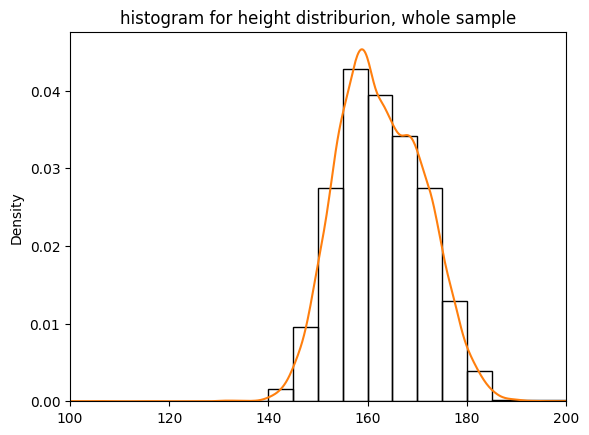

In [22]:
# ### 2) 그래프적 요약 (Graphical Summaries / Visualizations)
# | 시각화 기법 | 활용 용도 | Pandas / Seaborn 연동 코드 예시 |
# | **히스토그램 (Histogram)**
#           | 연속형 변수의 빈도 분포 및 왜도 파악     | `df['col'].plot(kind='hist', bins=30)` |

import matplotlib.pyplot as plt

df_dat['ht'].plot(kind='hist',
                  bins=b_class,
                  facecolor='None',
                  edgecolor='black',
                  density=True
                  )
df_dat['ht'].plot(kind='kde',
                  xlim=(100,200)
                  )
plt.title("histogram for height distriburion, whole sample")
#plt.xlim(100, 200) # 이것은 import matplotlib.pyplot as plt 후에.
# | **상자 그림 (Box Plot)**
#           | 사분위수, 중앙값, 이상치(Outlier) 식별  | `df.boxplot(column='col')` |
# | **산점도 (Scatter Plot)**
#           | 두 연속형 변수 간의 상관관계 및 패턴 파악 | `df.plot(kind='scatter', x='x_col', y='y_col')` |
# | **막대 그래프 (Bar Chart)**
#           | 범주형 변수의 범주별 빈도/비율 비교   | `df['category'].value_counts().plot(kind='bar')` |
# | **커널 밀도 추정 (KDE)**
#           | 연속형 변수의 확률 밀도 함수 추정     | `df['col'].plot(kind='kde')` |


### 히스토그램, 비교 - 각 -

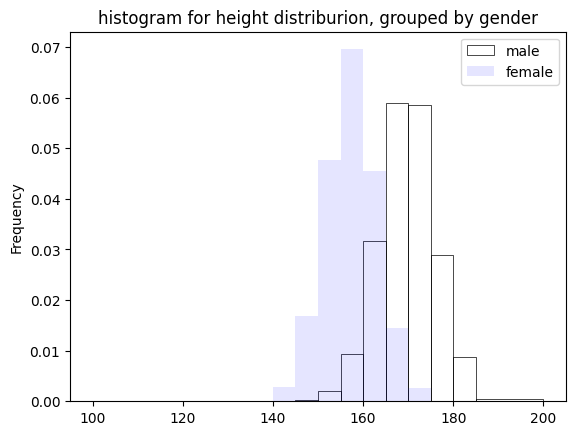

In [23]:
import matplotlib.pyplot as plt
df_dat['ht'][df_dat['gender']==1].plot(kind='hist',
                                       bins=b_class,
                                       facecolor='None',
                                       edgecolor='black',
                                       density=True,
                                       linewidth=0.5,
                                       label='male'
                                       )
df_dat['ht'][df_dat['gender']==2].plot(kind='hist',
                                       bins=b_class,
                                       facecolor='blue',
                                       edgecolor='None',
                                       density=True,
                                       label='female',
                                       alpha=0.1
                                       ) #linestyle='--')
plt.title("histogram for height distriburion, grouped by gender")
plt.legend()
plt.show()

### 히스토그램, 비교 - 커브 -
2개 그룹 비교(남, 여)

Text(0.5, 1.0, 'height distriburion, grouped by gender')

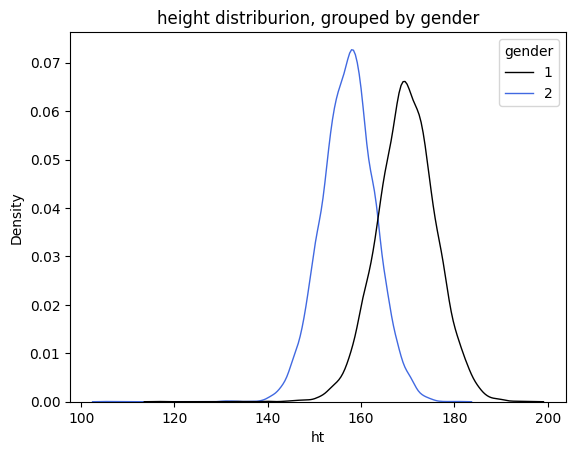

In [25]:
import seaborn as sns
# hue 옵션으로 성별에 따른 곡선을 한 그래프에 출력
gender_colors = {1 : 'black', 2 : 'royalblue'}  # 짝 맞춰서 색 지정, 딕셔너리 형태, 뒤에 나오는 커브,
sns.kdeplot(data=df_dat,
            x='ht',
            hue='gender',
            common_norm=False,      # 각 그룹별 비율을 1로 맞춤. 즉 전체면적 1로 통일.
            palette=gender_colors,
            linewidth=1.0
            )
plt.title("height distriburion, grouped by gender")


## 막대 그래프, 평균 비교
남-여 평균 키

Text(0.5, 1.0, 'height comparison across gender')

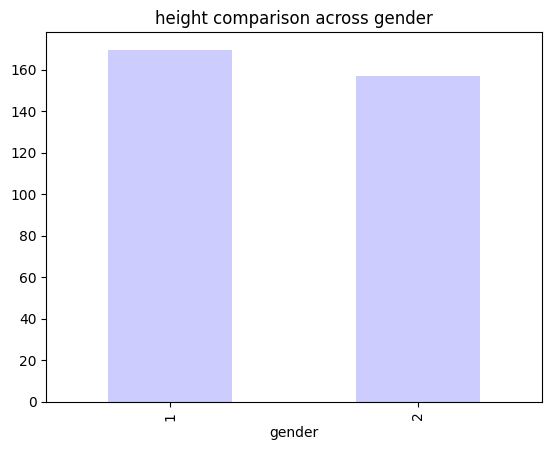

In [26]:
#  성별 평균키
df_dat.groupby('gender')['ht'].mean().plot(kind='bar', color="blue", alpha=0.2 )
plt.title("height comparison across gender")


In [19]:
# ## 3. 기타 기술 통계 관련 이슈

# 실무 데이터 분석 시 반드시 고려해야 하는 기술 통계적 이슈 및 파이썬 처리 기법입니다.

# ### 1) 결측치 (Missing Values) 처리

# * **기술 통계량 계산 시 영향:**
# **** NumPy(`np.mean`, `np.sum` 등)는 결측치(`NaN`)가 포함되어 있으면 결과가 `NaN`으로 출력됩니다.
#      (대안: `np.nanmean()`, `np.nansum()` 사용)
# **** Pandas 함수들은 기본적으로 `skipna=True`가 설정되어 있어 `NaN`을 제외하고 통계량을 계산합니다.

# * **대체 기법:** `df['col'].fillna(df['col'].median())` 등을 활용해 평균, 중앙값 또는 앞/뒤 값으로 대체합니다.


# ### 2) 자유도 (Degrees of Freedom, `ddof`) 설정 문제

# * 표본분산/표본표준편차 계산 시 분모를 $N$으로 나눌지, $N-1$로 나눌지에 대한 차이입니다.
# * **Pandas:** 기본 `ddof=1` (표본통계량 계산에 적합)
# * **NumPy:** 기본 `ddof=0` (모통계량 계산에 적합)

# * NumPy에서 표본표준편차를 구할 때는 반드시 `np.std(data, ddof=1)` 옵션을 지정해야 Pandas 결과와 일치합니다.


# ### 3) 이상치 (Outliers) 탐지 및 처리

# * **IQR 기반 탐지법:**
# * 하한선: $Q_1 - 1.5 \times \text{IQR}$
# * 상한선: $Q_3 + 1.5 \times \text{IQR}$
# * 이 범위를 벗어나는 데이터를 이상치로 판정하고
#      제거(`df.loc[...]`)하거나 윈저라이징(Clipping, `df['col'].clip(...)`) 처리합니다.


# ### 4) 범주형 데이터 및 교차분석 (Crosstab)

# * 두 개 이상의 범주형 변수 간의 관계를 분석할 때 교차표(Contingency Table)를 생성합니다.
# * `pd.crosstab(df['cat1'], df['cat2'], margins=True, normalize='all')`
#    구문을 통해 빈도수 및 비율을 한눈에 집계할 수 있습니다.

# ### 5) 상관관계 분석 (Correlation)

# * 연속형 변수 간의 선형적 관련성을 파악하기 위해 상관계수를 계산합니다.
# * `df.corr(method='pearson')` (비선형/순위 데이터의 경우 `method='spearman'` 활용).